**importing pandas, numpy, matplotlib**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

**mounting from drive**

In [2]:
from google.colab import drive
drive.mount("/content/Drive")

Mounted at /content/Drive


In [3]:
df = pd.read_csv("/content/Drive/MyDrive/dsml/new_titanic.csv")
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
576,577,1,2,"Garside, Miss. Ethel",female,34.0,0,0,243880,13.0000,NaN,S
255,256,1,3,"Touma, Mrs. Darwis (Hanne Youssef Razi)",female,29.0,0,2,2650,15.2458,NaN,C
426,427,1,2,"Clarke, Mrs. Charles V (Ada Maria Winfield)",female,28.0,1,0,2003,26.0000,NaN,S
113,114,0,3,"Jussila, Miss. Katriina",female,20.0,1,0,4136,9.8250,NaN,S
832,833,0,3,"Saad, Mr. Amin",male,NaN,0,0,2671,7.2292,NaN,C


**Renaming columns**

In [6]:
df.rename(columns = {
    "Pclass" : "Pstatus",
    "Sex" : "Gender"
},inplace = True)
df.columns

Index(['PassengerId', 'Survived', 'Pstatus', 'Name', 'Gender', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

**Handling Incorrect Data**

In [26]:
data = pd.DataFrame({
    "id" : [1,3,5,7,9],
    "name" : ["John","Jane","Jennifer","Johan","Jeff"],
    "age" : [25,-32,19,42,"55"],
    "gender" : ["M","M","Z","F","F"],
    "income" : [400,700,300,np.nan,600]
})

- removed negative from age and converted string into integer
- replaced the wrong gender notation with most frequent gender
- filled income with mean of income

In [31]:
data.age = data.age.astype(int).abs()
data.gender = [g if g in ["M","F"] else data.gender.mode()[0] for g in data.gender]
data.income = data.income.fillna(data.income.mean())

data

,id,name,age,gender,income
0,1,John,25,M,400.0
1,3,Jane,32,M,700.0
2,5,Jennifer,19,F,300.0
3,7,Johan,42,F,500.0
4,9,Jeff,55,F,600.0


In [32]:
data.dtypes

,0
id,int64
name,object
age,int64
gender,object
income,float64


**saving data**

In [33]:
data.to_csv("/content/Drive/MyDrive/dsml/new_data.csv",index = False)

In [34]:
data.to_json("/content/Drive/MyDrive/dsml/new_data.json",index = False, orient = "records")

In [37]:
data.to_json("new_data.json", orient = "columns")

**categorical datas**

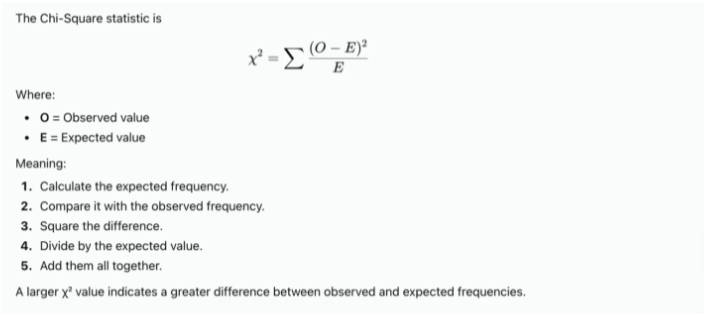

In [39]:
data = {
    "Gender" : ["Male","Male","Male","Female","Female","Female","Male","Female","Male","Female"],
    "Purchased" : ["Yes","No","Yes","No","Yes","No","Yes","No","Yes","Yes"]
}

df = pd.DataFrame(data)
df

,Gender,Purchased
0,Male,Yes
1,Male,No
2,Male,Yes
3,Female,No
4,Female,Yes
5,Female,No
6,Male,Yes
7,Female,No
8,Male,Yes
9,Female,Yes


In [40]:
contingency_table = pd.crosstab(df["Gender"], df["Purchased"])

In [41]:
contingency_table

Purchased,No,Yes
Gender,,
Female,3,2
Male,1,4


In [42]:
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(contingency_table)

In [43]:
print("Chi square statics:",chi2)
print("P-value:",p)
print("Degree of freedom:",dof)
print("Expected value:\n",expected)


Chi square statics: 0.41666666666666663
P-value: 0.5186050164287255
Degree of freedom: 1
Expected value:
 [[2. 3.]
 [2. 3.]]


In [44]:
alpha = 0.05

if alpha > p:
  print("There is a significant relationship")
else:
  print("No significant relationship")

No significant relationship
